In [1]:
import matplotlib.pyplot as plt
import awkward as ak
import numpy as np

from coffea.nanoevents import NanoEventsFactory, ScoutingNanoAODSchema
from coffea.analysis_tools import PackedSelection

import dask_awkward as dak

import itertools as iter

import hist
from hist import Hist
import hist.dask as hda

import vector as vec

import numba

In [2]:
file_list = [line.strip('\n') for line in open("filelists/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_0000.txt").readlines()] # + [line.strip('\n') for line in open("filelists/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_0001.txt").readlines()] + [line.strip('\n') for line in open("filelists/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_0002.txt").readlines()]
file_list = ["root://cmseos.fnal.gov//" + string for string in file_list]



ScoutingNanoAODSchema.warn_missing_crossrefs = False

small_events = NanoEventsFactory.from_root(
    {file : "Events" for file in file_list[0:1]},
    schemaclass=ScoutingNanoAODSchema,
    metadata={"dataset": "HadronicTops"},
).events()

small_events = small_events[:10_000]

/uscms/home/jlawless/nobackup/miniforge3/lib/python3.10/site-packages/coffea/nanoevents/methods/candidate.py:11: FutureWarning: In version 2025.1.0 (target date: 2024-12-31 11:59:59-06:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  from coffea.nanoevents.methods import vector


In [3]:
truth = small_events.GenPart[(abs(small_events.GenPart.pdgId) == 24) & ( small_events.GenPart.hasFlags(['isLastCopy','isPrompt']))]

w_to_jets_cut = (abs(truth.children[:,:,0].pdgId) == 1) | (abs(truth.children[:,:,0].pdgId) == 2) | (abs(truth.children[:,:,0].pdgId) == 3) | (abs(truth.children[:,:,0].pdgId) == 4)

w_truth = truth[w_to_jets_cut]
w_truth = w_truth[ak.num(w_truth, axis=1) > 0]
w_truth = w_truth[:,0]
w_jets_truth = w_truth.children
w_jets_truth = w_jets_truth[ak.num(w_jets_truth, axis=1) > 1]

(array([  6.,  14.,  38.,  71.,  67.,  60.,  60.,  62.,  60.,  58.,  64.,
         88.,  92., 105., 132., 182., 242., 297., 398., 458., 520., 609.,
        644., 682., 539., 461., 357., 316., 270., 212., 189., 152., 139.,
        144., 153., 134., 118., 114.,  95., 100.,  78.,  82.,  71.,  89.,
         60.,  69.,  61.,  55.,  50.,  55.,  37.,  37.,  46.,  25.,  33.,
         17.,  37.,  23.,  31.,  23.,  16.,  24.,  32.,  27.,  18.,  17.,
         26.,  17.,  11.,  13.,  14.,  18.,  12.,  15.,  12.]),
 array([  0.        ,   3.33333325,   6.66666651,  10.        ,
         13.33333302,  16.66666603,  20.        ,  23.33333397,
         26.66666603,  30.        ,  33.33333206,  36.66666794,
         40.        ,  43.33333206,  46.66666794,  50.        ,
         53.33333206,  56.66666794,  60.        ,  63.33333206,
         66.66666412,  70.        ,  73.33333588,  76.66666412,
         80.        ,  83.33333588,  86.66666412,  90.        ,
         93.33333588,  96.66666412, 100.    

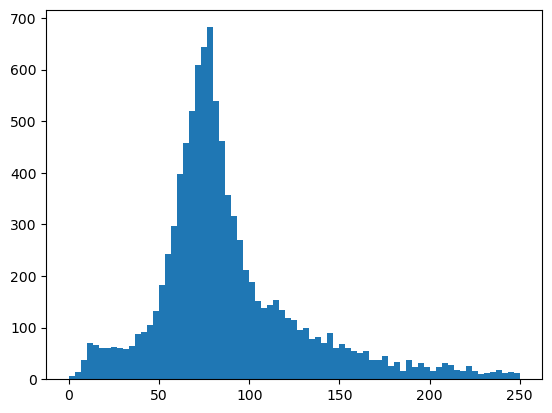

In [4]:
first_jet = w_jets_truth[:,0]
second_jet = w_jets_truth[:,1]

# first_jet.nearest(small_events.ScoutingJet).compute()


candidate_one = small_events.ScoutingJet[ak.local_index(small_events.ScoutingJet,axis=1) == ak.argmin(first_jet.delta_r(small_events.ScoutingJet),axis=1)]
candidate_two = small_events.ScoutingJet[ak.local_index(small_events.ScoutingJet,axis=1) == ak.argmin(second_jet.delta_r(small_events.ScoutingJet),axis=1)]

w_candid = candidate_one + candidate_two

plt.hist(w_candid.mass.compute(),
         range = (0, 250),
         bins= 75)

(array([  0.,   1.,   1.,   4.,  11.,  11.,   4.,   7.,   4.,   5.,   7.,
          5.,   6.,  15.,   9.,  10.,   6.,  15.,  22.,  24.,  41.,  46.,
         47.,  58.,  93.,  99., 130., 140., 154., 170., 207., 247., 273.,
        319., 336., 382., 413., 415., 433., 389., 435., 400., 392., 299.,
        284., 245., 236., 220., 177., 161., 157., 153., 120.,  92., 108.,
         81.,  84.,  86.,  75.,  74.,  85.,  61.,  64.,  57.,  56.,  46.,
         57.,  46.,  37.,  47.,  42.,  24.,  26.,  43.,  43.]),
 array([  0.,   4.,   8.,  12.,  16.,  20.,  24.,  28.,  32.,  36.,  40.,
         44.,  48.,  52.,  56.,  60.,  64.,  68.,  72.,  76.,  80.,  84.,
         88.,  92.,  96., 100., 104., 108., 112., 116., 120., 124., 128.,
        132., 136., 140., 144., 148., 152., 156., 160., 164., 168., 172.,
        176., 180., 184., 188., 192., 196., 200., 204., 208., 212., 216.,
        220., 224., 228., 232., 236., 240., 244., 248., 252., 256., 260.,
        264., 268., 272., 276., 280., 284., 288.

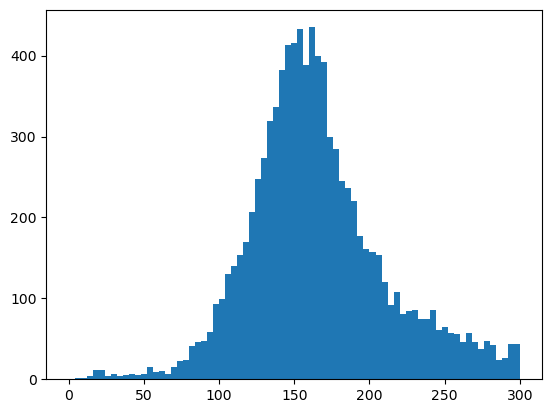

In [9]:
truth_b = small_events.GenPart[(abs(small_events.GenPart.pdgId) == 5) & ( small_events.GenPart.hasFlags(['isLastCopy'])) & (small_events.GenPart.distinctParentIdxG == w_truth.distinctParentIdxG)]
#truth_b = truth_b[ak.num(truth_b, axis=1) > 0]
truth_b = ak.firsts(truth_b)
candidate_b = small_events.ScoutingJet[ak.local_index(small_events.ScoutingJet,axis=1) == ak.argmin(truth_b.delta_r(small_events.ScoutingJet),axis=1)]

top_candidate = w_candid + candidate_b

plt.hist(top_candidate.mass.compute(),
         range = (0, 300),
         bins= 75)

In [40]:
ak.local_index(small_events.ScoutingJet,axis=1).compute()

<Array [[0, 1, 2, 3, 4, 5], [...], ..., [0, 1, 2, 3]] type='30 * var * int64'>

In [37]:
ak.argmin(first_jet.delta_r(small_events.ScoutingJet),axis=1).compute()

<Array [3, 0, 3, 2, 6, 2, 1, 0, ..., 5, 4, 2, 1, 2, 2, 2, 2] type='30 * ?int64'>

In [17]:
parts = small_events.GenPart
cut = (parts.pdgId == -11) | (parts.pdgId == 11) 

val = ak.sum(ak.num(parts[cut].pdgId,axis=1) > 0) / ak.num(parts,axis=0)

val.compute()

0.9624712564611545

In [9]:
small_events.ScoutingJet.particleNet_prob_b.compute()

<Array [[1.2e-24, 0, 2.82e-25, ..., 0, 0], ...] type='610572 * var * float3...'>

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


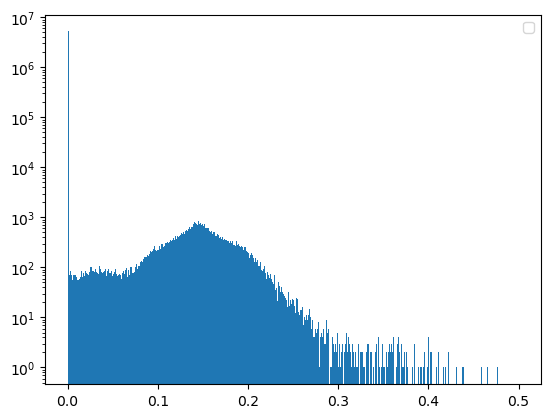

In [5]:
plt.hist(
    ak.flatten(small_events.ScoutingJet.particleNet_prob_b).compute(),
    bins= 500,
    range=(0,0.5)
    )

#y axis is in pico-barns, need to multiply by luminosity to get num events
#lum in inverse pico-barns
plt.yscale('log')
plt.legend()

In [8]:
ak.num(small_events, axis=0).compute()

610572

In [11]:
cut = (ak.num(small_events.ScoutingJet) >= 4) & (small_events.ScoutingMET.pt > 40) & (ak.sum(small_events.ScoutingJet.particleNet_prob_b < 0.001 ,axis=1) > 1)
w_jet_cut = small_events[cut].ScoutingJet.particleNet_prob_b < 0.001 
non_b_jets = small_events[cut].ScoutingJet[w_jet_cut]
w_candidate = non_b_jets[:,0] + non_b_jets[:,1]

w_candidate.mass.compute()

<Array [121, 331, 162, 415, ..., 328, 238, 229, 279] type='434270 * float32'>

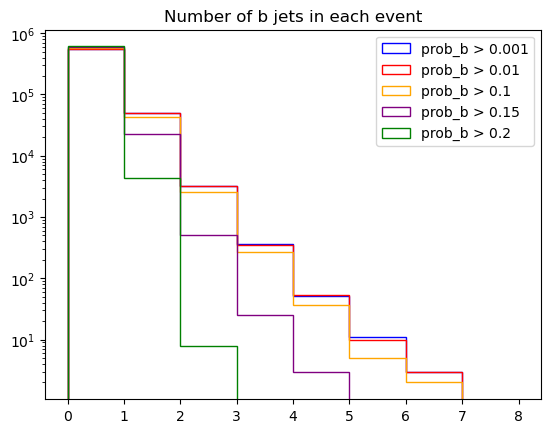

In [6]:
#cut_ev = small_events[(ak.num(small_events.ScoutingJet) >= 4)]

plt.hist(
    ak.sum(small_events.ScoutingJet.particleNet_prob_b > 0.001 ,axis=1).compute(),
    bins= 8,
    range=(0,8),
    histtype='step',
    color="blue",
    label="prob_b > 0.001"
    )
plt.hist(
    ak.sum(small_events.ScoutingJet.particleNet_prob_b > 0.01 ,axis=1).compute(),
    bins= 8,
    range=(0,8),
    histtype='step',
    color="red",
    label="prob_b > 0.01"
    )
plt.hist(
    ak.sum(small_events.ScoutingJet.particleNet_prob_b > 0.1 ,axis=1).compute(),
    bins= 8,
    range=(0,8),
    histtype='step',
    color="orange",
    label="prob_b > 0.1"
    )
plt.hist(
    ak.sum(small_events.ScoutingJet.particleNet_prob_b > 0.15, axis=1).compute(),
    bins= 8,
    range=(0,8),
    histtype='step',
    color="purple",
    label="prob_b > 0.15"
    )
plt.hist(
    ak.sum(small_events.ScoutingJet.particleNet_prob_b > 0.2 ,axis=1).compute(),
    bins= 8,
    range=(0,8),
    histtype='step',
    color="green",
    label="prob_b > 0.2"
    )


#y axis is in pico-barns, need to multiply by luminosity to get num events
#lum in inverse pico-barns
plt.title("Number of b jets in each event")
plt.legend()
plt.yscale('log')